epoch  200 | train MSE: 0.03714
epoch  400 | train MSE: 0.03280
epoch  600 | train MSE: 0.03401
epoch  800 | train MSE: 0.02211
epoch 1000 | train MSE: 0.02503
epoch 1200 | train MSE: 0.02358
epoch 1400 | train MSE: 0.01897
epoch 1600 | train MSE: 0.01957
epoch 1800 | train MSE: 0.02019
epoch 2000 | train MSE: 0.02198


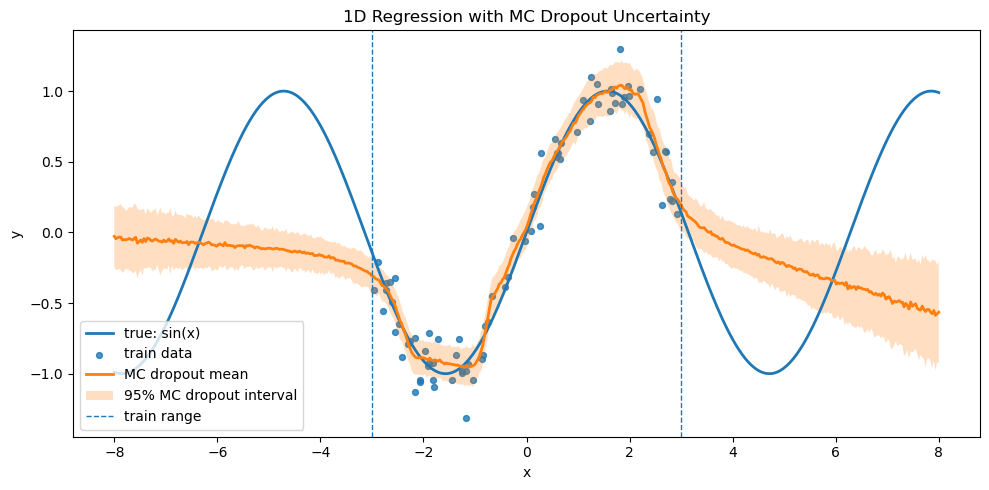

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# Toy data: y = sin(x) + noise, train on a limited range to show epistemic uncertainty
# -----------------------
def make_data(n_train=80, noise_std=0.15):
    # Train in a limited interval
    x_train = np.random.uniform(-3.0, 3.0, size=(n_train, 1)).astype(np.float32)
    y_train = np.sin(x_train) + noise_std * np.random.randn(n_train, 1).astype(np.float32)

    # Test on a wider interval for extrapolation
    x_test = np.linspace(-8.0, 8.0, 500, dtype=np.float32).reshape(-1, 1)
    y_true = np.sin(x_test)

    return x_train, y_train, x_test, y_true

x_train, y_train, x_test, y_true = make_data()

x_train_t = torch.from_numpy(x_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
x_test_t  = torch.from_numpy(x_test).to(device)

# -----------------------
# Model: MLP with dropout
# -----------------------
class MCDropoutMLP(nn.Module):
    def __init__(self, in_dim=1, hidden=64, p_drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MCDropoutMLP(p_drop=0.1).to(device)

# -----------------------
# Train
# -----------------------
def train(model, x, y, epochs=2000, lr=1e-3, weight_decay=1e-6, verbose_every=200):
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs + 1):
        opt.zero_grad(set_to_none=True)
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()

        if verbose_every and ep % verbose_every == 0:
            print(f"epoch {ep:4d} | train MSE: {loss.item():.5f}")

train(model, x_train_t, y_train_t)

# -----------------------
# MC Dropout prediction
# -----------------------
@torch.no_grad()
def mc_predict(model, x, T=200):
    """
    Returns:
      mean: (N, 1)
      std:  (N, 1) epistemic uncertainty estimate from MC dropout
      samples: (T, N, 1)
    """
    model.train()  # IMPORTANT: keep dropout ON at test time
    samples = []
    for _ in range(T):
        samples.append(model(x).unsqueeze(0))
    samples = torch.cat(samples, dim=0)        # (T, N, 1)
    mean = samples.mean(dim=0)                 # (N, 1)
    std  = samples.std(dim=0, unbiased=False)  # (N, 1)
    return mean, std, samples

mean_t, std_t, _ = mc_predict(model, x_test_t, T=200)

mean = mean_t.cpu().numpy().squeeze()
std  = std_t.cpu().numpy().squeeze()

# 95% interval (approx)
lower = mean - 1.96 * std
upper = mean + 1.96 * std

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10, 5))
plt.plot(x_test.squeeze(), y_true.squeeze(), linewidth=2, label="true: sin(x)")
plt.scatter(x_train.squeeze(), y_train.squeeze(), s=18, alpha=0.8, label="train data")
plt.plot(x_test.squeeze(), mean, linewidth=2, label="MC dropout mean")
plt.fill_between(x_test.squeeze(), lower, upper, alpha=0.25, label="95% MC dropout interval")
plt.axvline(-3.0, linestyle="--", linewidth=1, label="train range")
plt.axvline( 3.0, linestyle="--", linewidth=1)
plt.title("1D Regression with MC Dropout Uncertainty")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()